# Dictionary vector space tutorial
In this tutorial you will learn:
- How to construct a vector space using a snapshot data tensor

In [1]:
#First, let's import the relavant modules:
import romtools
import numpy as np
from matplotlib import pyplot as plt
from romtools import vector_space

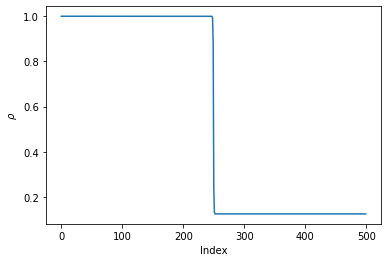

In [2]:
#Now, we will load in snapshots from a FOM. Here, we use pre-computed snapshots of the 1D Euler equations obtained using pressio-demo-apps
snapshots = np.load('snapshots.npz')['snapshots']

## The snapshots are in tensor form:
n_vars, nx, nt = snapshots.shape
## Note that romtools works with tensor forms (https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space.html)

#Let's look at the first density snapshot:

plt.plot(snapshots[0,:,0])
plt.xlabel(r'Index')
plt.ylabel(r'$\rho$')
plt.show()

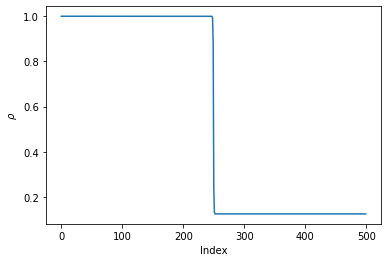

In [3]:
#Now, let's make a dictionary basis (no truncation) that uses the first vector as an affine offset
#First, let's create a "shifter" that is responsible for shifting snapshots
#(https://pressio.github.io/rom-tools-and-workflows/romtools/vector_space/utils/shifter.html)
my_shifter = vector_space.utils.create_firstvec_shifter(snapshots)

#We can look at the shift vector if we want:
shift_vec = my_shifter.get_shift_vector()
plt.plot(shift_vec[0])
plt.xlabel(r'Index')
plt.ylabel(r'$\rho$')
plt.show()

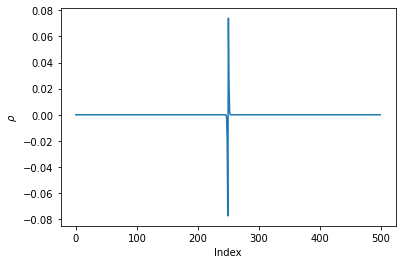

In [4]:
#Now, let's construct an affine vector space using this as a shifter
#Note we don't use the first snapshot in the vector space since this is the affine offset
my_affine_vector_space = vector_space.DictionaryVectorSpace(snapshots[...,1::],shifter=my_shifter)

##It's important to note that we do not do a deep copy of the snapshot matrix for performance reasons.
##Once you pass us the snapshot tensor, we will modify the data in place. 


#What if I didn't what an affine offset? We can just do:
#my_vector_space = vector_space.DictionaryVectorSpace(snapshots)

#We can view the basis and shift vector:
basis = my_affine_vector_space.get_basis()
shift_vector = my_affine_vector_space.get_shift_vector()

#We can look at the density compoenent of the first basis:
plt.plot(basis[0,:,0])
plt.xlabel(r'Index')
plt.ylabel(r'$\rho$')
plt.show()